### HALO Hackathon - EDA
The data being explored here is tracking enhanced data from 480 games in the 2023-2024 AHL season. 

The data is available in five separate datasets:
- `games`: one record per game with team and outcome information
- `events`: one record per event
- `stints`: one record per player per stint (a stretch of play during which a set of distinct players is on the ice)
- `players`: one record per player
- `tracking`: one record per player per event

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style="darkgrid")

load_dotenv()
DATA = os.getenv("DATA")

EDA on `games_df`

In [2]:
games_df = pd.read_parquet(f"{DATA}/games.parquet")
print(games_df.shape)
print(games_df.dtypes)
games_df.head()

(480, 12)
game_id              str
game_date         object
league               str
season             int64
home_team            str
away_team            str
home_team_id         str
away_team_id         str
home_score         int64
away_score         int64
game_outcome         str
home_start_net       str
dtype: object


,game_id,game_date,league,season,home_team,away_team,home_team_id,away_team_id,home_score,away_score,game_outcome,home_start_net
0,0f51a5c7-6d54-1917-d4a5-9e83a0b4a1ea,2024-04-20,AHL,2023,CHI,IA,2fddd6bd-144f-ca64-90e3-8d36f96c8b28,50030ea0-2c9b-66e2-a36c-bab16b79492c,2,3,away_win,pos_x
1,0f1f9e60-c5cc-30e1-f520-e92f2da2ae08,2024-04-20,AHL,2023,BAK,HEN,19188913-73c8-34a7-d02a-5d1c3e58a191,411d86dc-8d7b-5507-c28d-87aa160b61cc,5,3,home_win,neg_x
2,1a0aceea-b3da-60e0-4c5c-0ba532fa6731,2024-04-20,AHL,2023,ABB,CAL,971502f4-80be-6e90-0bfb-3a60367a24ff,fbd255f8-427d-f29b-e83e-6c631c75899a,3,2,home_win,pos_x
3,609644d8-b5b8-8973-339a-53ca2c0d4ce1,2024-04-20,AHL,2023,HER,CLT,c1cd64c9-e2fd-7a1a-269a-aa5a8e422cbb,2251a5f6-9710-c610-8d44-9f2e4f4fc7a2,1,4,away_win,neg_x
4,2730a3bf-1f50-b700-7bd4-f01369b5e5cf,2024-04-20,AHL,2023,TEX,MB,9bfe142b-8c31-828f-dde8-a252d75d5ef3,1f9a39ec-18eb-166c-d1ed-5dfb9343f764,1,4,away_win,neg_x


In [3]:
print("Nulls per column:")
print(games_df.isna().sum())
print()
print(f"Date range: {games_df['game_date'].min()} to {games_df['game_date'].max()}")
print(f"League(s): {games_df['league'].unique()}")
print(f"Season(s): {games_df['season'].unique()}")
print(f"Teams: {games_df['home_team'].nunique()} unique")

Nulls per column:
game_id           0
game_date         0
league            0
season            0
home_team         0
away_team         0
home_team_id      0
away_team_id      0
home_score        0
away_score        0
game_outcome      0
home_start_net    0
dtype: int64

Date range: 2023-10-13 to 2024-04-21
League(s): <ArrowStringArray>
['AHL']
Length: 1, dtype: str
Season(s): [2023]
Teams: 32 unique


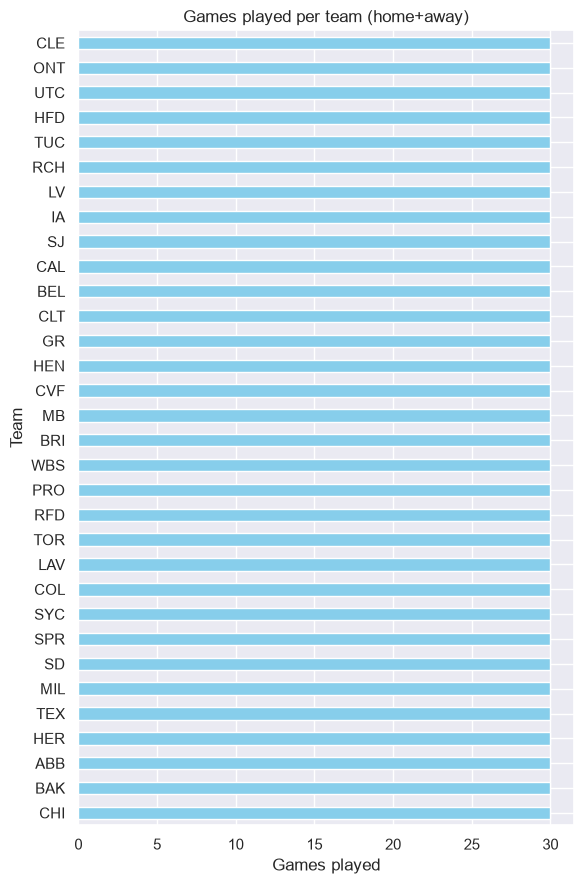

In [4]:
games_per_team = (
    pd.concat([games_df['home_team'], games_df['away_team']])
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 9))
games_per_team.plot(kind="barh", ax=ax, color = "skyblue")
ax.set_xlabel("Games played")
ax.set_ylabel("Team")
ax.set_title("Games played per team (home+away)")
plt.tight_layout()
plt.show()

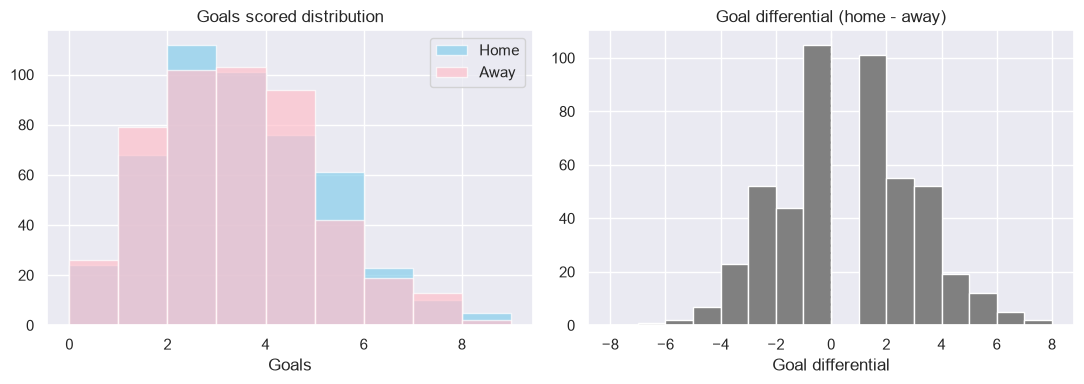

Mean total goals/game: 5.94


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(games_df["home_score"], bins=range(0, 10), alpha=0.7, label="Home", color="#38bdf8")
axes[0].hist(games_df["away_score"], bins=range(0, 10), alpha=0.7, label="Away", color="#f472b6")
axes[0].set_title("Goals scored distribution")
axes[0].set_xlabel("Goals")
axes[0].legend()

goal_diff = games_df["home_score"] - games_df["away_score"]
axes[1].hist(goal_diff, bins=range(-8, 9), color="gray")
axes[1].axvline(0, color="white", linestyle="--", linewidth=1)
axes[1].set_title("Goal differential (home - away)")
axes[1].set_xlabel("Goal differential")
plt.tight_layout()
plt.show()

print(f"Mean total goals/game: {(games_df['home_score'] + games_df['away_score']).mean():.2f}")

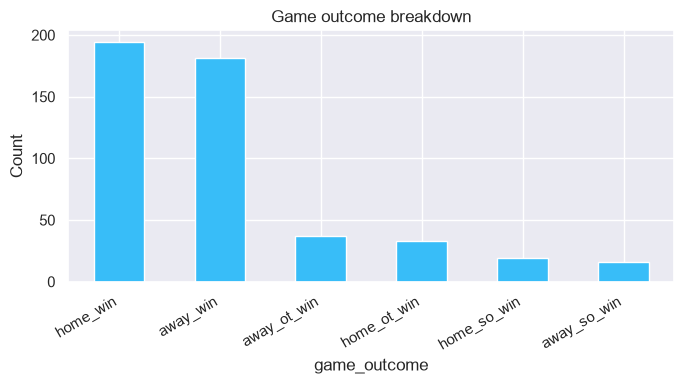

Home win rate (incl. OT/SO): 51.2%


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
games_df["game_outcome"].value_counts().plot(kind="bar", ax=ax, color="#38bdf8")
ax.set_title("Game outcome breakdown")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

home_win_types = {"home_win", "home_ot_win", "home_so_win"}
home_win_rate = games_df["game_outcome"].isin(home_win_types).mean()
print(f"Home win rate (incl. OT/SO): {home_win_rate:.1%}")

EDA on `players_df`

In [7]:
players_df = pd.read_parquet(f"{DATA}/players.parquet")
print(players_df.shape)
print(players_df.dtypes)
players_df.head()

(1172, 8)
player_id              str
player_name            str
last_name              str
first_name             str
handed                 str
birth_date          object
position_group         str
primary_position       str
dtype: object


,player_id,player_name,last_name,first_name,handed,birth_date,position_group,primary_position
0,58ff86bf-e659-f9dc-3f5f-6a51741e47ab,"Zohorna, Radim",Zohorna,Radim,L,1996-04-29,F,C
1,87bd2512-ca41-d650-0517-297bbfc26a41,"Philp, Luke",Philp,Luke,R,1995-11-06,F,C
2,cb889642-eedd-496a-9c02-563f569c6359,"Roos, Filip",Roos,Filip,L,1999-01-05,D,D
3,69c1e284-b220-e453-250a-66413a82618e,"Studenic, Marian",Studenic,Marian,L,1998-10-28,F,LW
4,f8513815-ad09-b742-fef8-9814f2313b80,"Steen, Oskar",Steen,Oskar,R,1998-03-09,F,RW


In [8]:
print("Nulls per column:")
print(players_df.isna().sum())

Nulls per column:
player_id           0
player_name         0
last_name           0
first_name          0
handed              0
birth_date          0
position_group      0
primary_position    0
dtype: int64


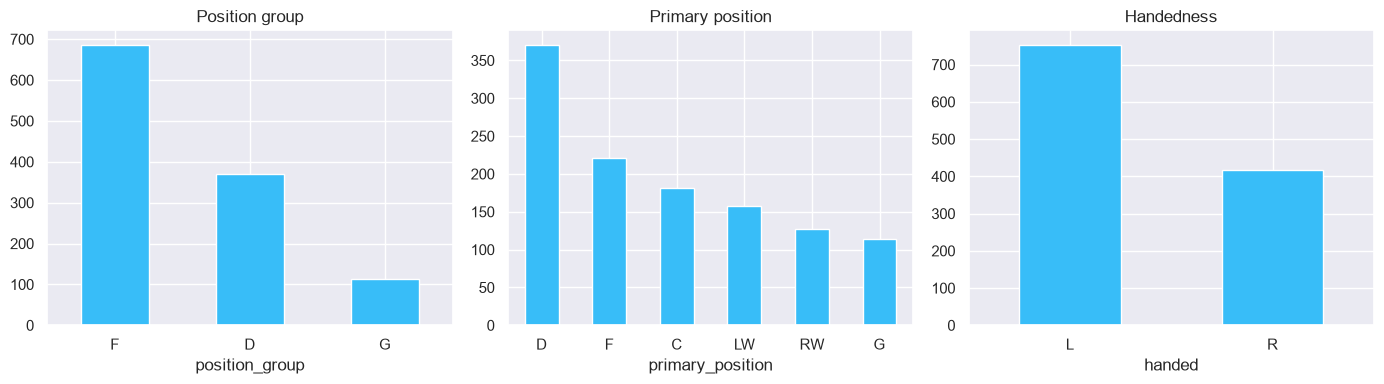

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

players_df["position_group"].value_counts().plot(kind="bar", ax=axes[0], color="#38bdf8")
axes[0].set_title("Position group")

players_df["primary_position"].value_counts().plot(kind="bar", ax=axes[1], color="#38bdf8")
axes[1].set_title("Primary position")

players_df["handed"].value_counts().plot(kind="bar", ax=axes[2], color="#38bdf8")
axes[2].set_title("Handedness")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

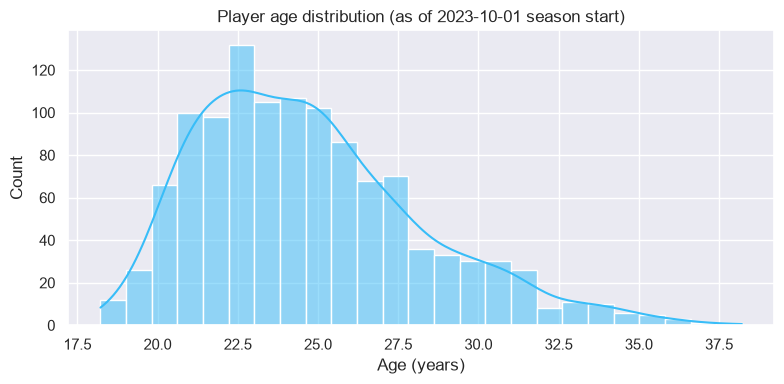

count    1172.000000
mean       24.721155
std         3.479241
min        18.220397
25%        22.140999
50%        24.295688
75%        26.635181
max        38.212183
Name: birth_date, dtype: float64


In [10]:
season_start = pd.Timestamp("2023-10-01")
birth_date = pd.to_datetime(players_df["birth_date"].astype(str))
age_years = (season_start - birth_date).dt.days / 365.25

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(age_years, bins=25, kde=True, ax=ax, color="#38bdf8")
ax.set_title("Player age distribution (as of 2023-10-01 season start)")
ax.set_xlabel("Age (years)")
plt.tight_layout()
plt.show()

print(age_years.describe())


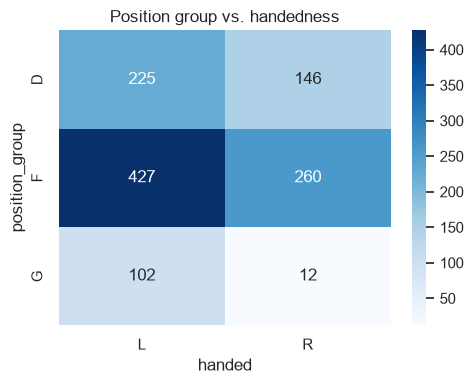

In [11]:
cross = pd.crosstab(players_df["position_group"], players_df["handed"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Position group vs. handedness")
plt.tight_layout()
plt.show()


EDA on `stints_df`

In [12]:
stints_df = pd.read_parquet(f"{DATA}/stints.parquet")
print(stints_df.shape)
print(stints_df.dtypes)
stints_df.head()

(2212064, 15)
game_id                 str
period                int64
period_time_start    object
period_time_end      object
game_stint            int64
n_home_skaters        int64
n_away_skaters        int64
is_home_net_empty      bool
is_away_net_empty      bool
home_score            int64
away_score            int64
player_id               str
player_name             str
team_id                 str
team                    str
dtype: object


,game_id,period,period_time_start,period_time_end,game_stint,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,player_id,player_name,team_id,team
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,31.000000000,1,5,5,False,False,0,0,9cdb062f-6fc7-e205-1858-d4f6f32237a4,"Johansson, Albert",6cac12e2-0546-2c1a-689f-ab26d8a6355a,GR
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,31.000000000,1,5,5,False,False,0,0,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,CLE
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,31.000000000,1,5,5,False,False,0,0,0753b094-9e2f-976d-85c8-d22a1d280e8d,"Jiricek, David",d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,CLE
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,31.000000000,1,5,5,False,False,0,0,8682f8c1-304a-51d9-6663-158ca58fa6c9,"Didier, Josiah",6cac12e2-0546-2c1a-689f-ab26d8a6355a,GR
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,31.000000000,1,5,5,False,False,0,0,6eb5f6c3-b657-5df9-6027-43ce18a2cca6,"Greaves, Jet",d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,CLE


In [13]:
print("Nulls per column:")
print(stints_df.isna().sum())
print()
print(f"Unique games: {stints_df['game_id'].nunique()}")
print(f"Unique players: {stints_df['player_id'].nunique()}")
print(f"Unique teams: {stints_df['team'].nunique()}")

Nulls per column:
game_id              0
period               0
period_time_start    0
period_time_end      0
game_stint           0
n_home_skaters       0
n_away_skaters       0
is_home_net_empty    0
is_away_net_empty    0
home_score           0
away_score           0
player_id            0
player_name          0
team_id              0
team                 0
dtype: int64

Unique games: 480
Unique players: 1172
Unique teams: 32


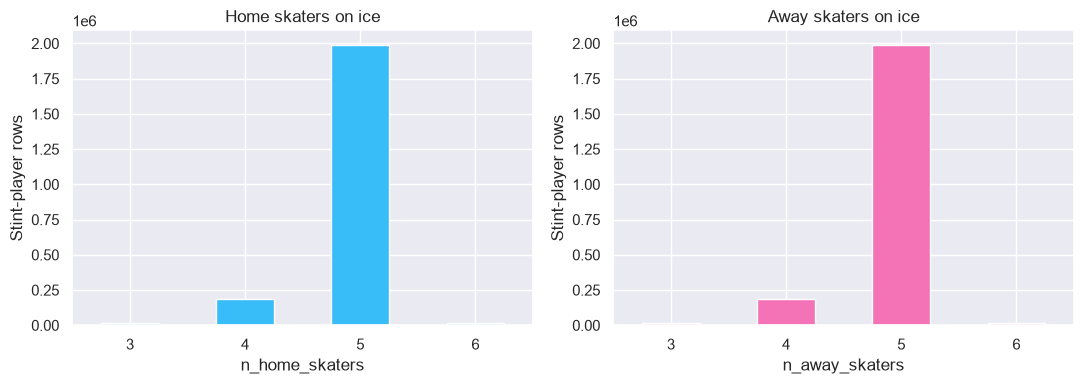

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stints_df["n_home_skaters"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#38bdf8")
axes[0].set_title("Home skaters on ice")
stints_df["n_away_skaters"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#f472b6")
axes[1].set_title("Away skaters on ice")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylabel("Stint-player rows")
plt.tight_layout()
plt.show()

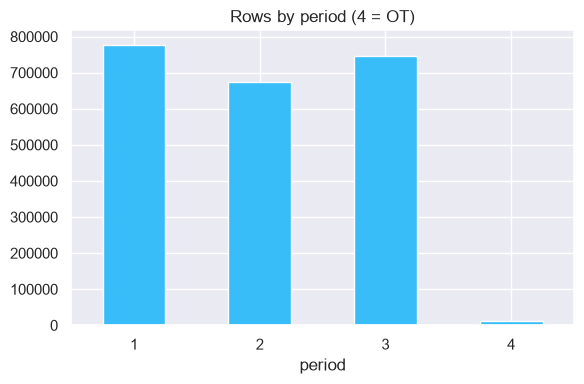

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
stints_df["period"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#38bdf8")
ax.set_title("Rows by period (4 = OT)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

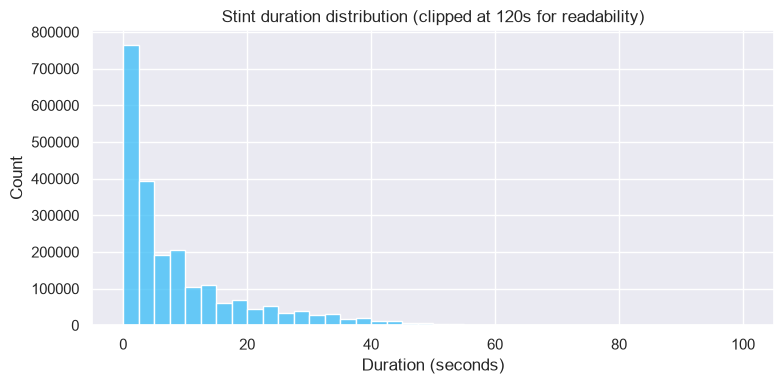

count    2.212064e+06
mean     9.255990e+00
std      1.083516e+01
min      3.000000e-02
25%      2.000000e+00
50%      5.000000e+00
75%      1.236000e+01
max      1.920000e+02
dtype: float64


In [16]:
duration = (
    stints_df["period_time_end"].astype(float) - stints_df["period_time_start"].astype(float)
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(duration.clip(upper=100), bins=40, ax=ax, color="#38bdf8")
ax.set_title("Stint duration distribution (clipped at 120s for readability)")
ax.set_xlabel("Duration (seconds)")
plt.tight_layout()
plt.show()

print(duration.describe())


EDA on `events_df`

In [17]:
events_df = pd.read_parquet(f"{DATA}/events.parquet")
print(events_df.shape)
print(events_df.dtypes)
events_df.head()

(1800464, 24)
game_id                     str
period                    int64
period_time              object
game_stint              float64
sl_event_id               int64
sequence_id               int64
player_id                   str
player_name                 str
team                        str
team_id                     str
opp_team                    str
opp_team_id                 str
event_type                  str
outcome                     str
flags                       str
description                 str
detail                      str
sl_xg_all_shots         float64
x                       float64
y                       float64
x_adj                   float64
y_adj                   float64
has_tracking_data         int64
event_player_tracked      int64
dtype: object


,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,...,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,0,1,NaN,NaN,NaN,NaN,...,NaN,Face-Off,nz,NaN,NaN,NaN,NaN,NaN,1,0
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,1,1,8cdcb61e-d733-bde6-a101-ef3140e48149,"L'Esperance, Joel",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,...,"centerfodot, righthandedopponent",NZ FACE OFF-,none,NaN,-0.201431,-0.755550,-0.201431,-0.755550,1,1
2,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0E-9,1.0,2,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,"centerfodot, righthandedopponent",NZ REC FACE OFF+ENTRY,recoveredwithentry,NaN,-0.201431,-0.755550,0.201431,0.755550,1,1
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0.070000000,1.0,3,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,NaN,F/OFF LPR+ NZ,faceoff,NaN,0.807243,1.257381,-0.807243,-1.257381,1,1
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0.130000000,1.0,4,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,eastside,NZPASS south+,south,NaN,0.304306,0.845894,-0.304306,-0.845894,1,1


In [18]:
events_df[events_df['event_type']=='lpr'].head(5)

,game_id,period,period_time,game_stint,sl_event_id,sequence_id,player_id,player_name,team,team_id,...,flags,description,detail,sl_xg_all_shots,x,y,x_adj,y_adj,has_tracking_data,event_player_tracked
3,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,0.070000000,1.0,3,1,dc5a9c10-c8d3-52bc-fd80-b7186f383b34,"McKown, Hunter",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,NaN,F/OFF LPR+ NZ,faceoff,NaN,0.807243,1.257381,-0.807243,-1.257381,1,1
10,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,9.270000000,1.0,10,1,8682f8c1-304a-51d9-6663-158ca58fa6c9,"Didier, Josiah",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,...,alongboards,LPR+ DZ,error,NaN,-96.260400,-13.327915,-96.260400,-13.327915,0,0
14,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,16.330000000,1.0,14,1,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,"Bjork, Marcus",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,alongboards,HI PRESS DUMP IN LPR+,hipresopdump,NaN,71.219010,39.983852,-71.219010,-39.983852,0,0
20,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,27.930000000,1.0,20,1,8682f8c1-304a-51d9-6663-158ca58fa6c9,"Didier, Josiah",GR,6cac12e2-0546-2c1a-689f-ab26d8a6355a,...,alongboards,LPR+ NZ,error,NaN,-12.772163,-35.457330,-12.772163,-35.457330,1,1
23,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,30.400000000,1.0,23,1,cb8a6b8b-c5a6-4bfe-10b7-15c784b83a7d,"Bjork, Marcus",CLE,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,...,alongboards,DUMP IN LPR+,opdump,NaN,47.580780,-33.948500,-47.580780,33.948500,1,1


In [19]:
print("Nulls per column:")
print(events_df.isna().sum())

Nulls per column:
game_id                       0
period                        0
period_time                   0
game_stint                 1053
sl_event_id                   0
sequence_id                   0
player_id                 64310
player_name               64310
team                      64310
team_id                   64310
opp_team                  64310
opp_team_id               64310
event_type                    0
outcome                   64310
flags                    990106
description                   0
detail                        0
sl_xg_all_shots         1746484
x                         64310
y                         64310
x_adj                     64310
y_adj                     64310
has_tracking_data             0
event_player_tracked          0
dtype: int64


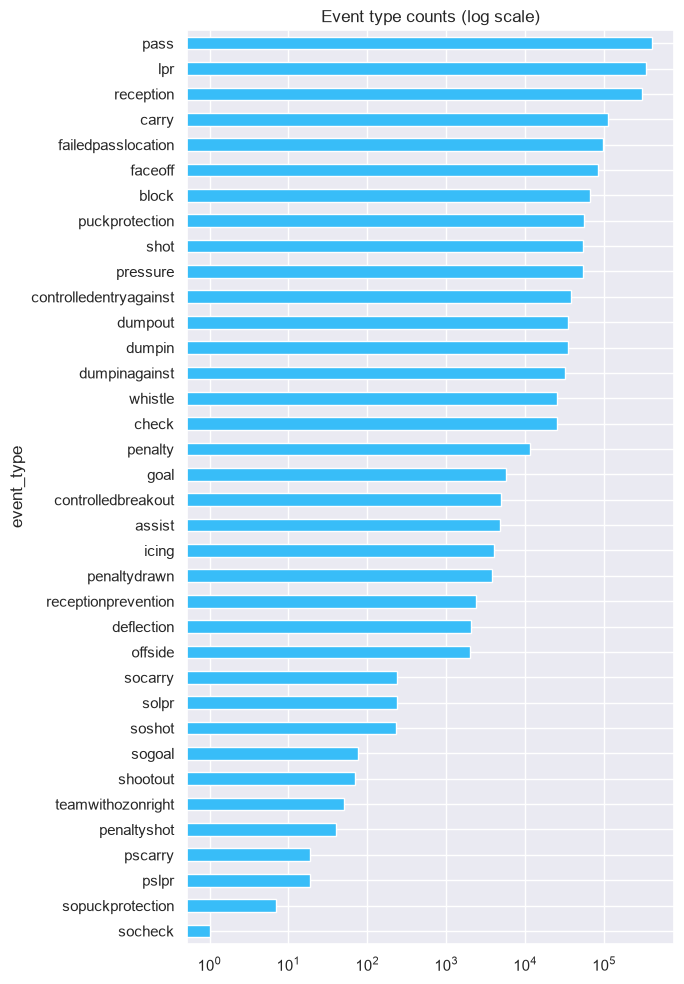

In [20]:
fig, ax = plt.subplots(figsize=(7, 10))
events_df["event_type"].value_counts().sort_values().plot(kind="barh", ax=ax, color="#38bdf8")
ax.set_title("Event type counts (log scale)")
ax.set_xscale("log")
plt.tight_layout()
plt.show()


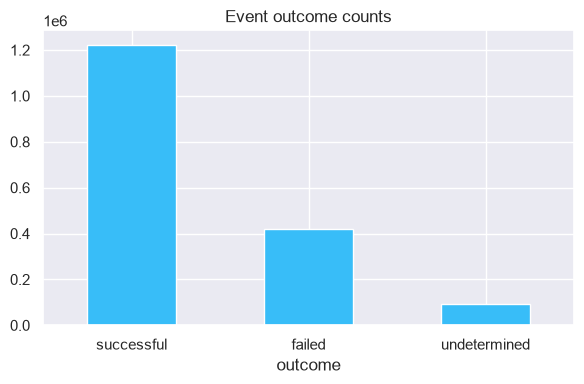

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
events_df["outcome"].value_counts().plot(kind="bar", ax=ax, color="#38bdf8")
ax.set_title("Event outcome counts")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

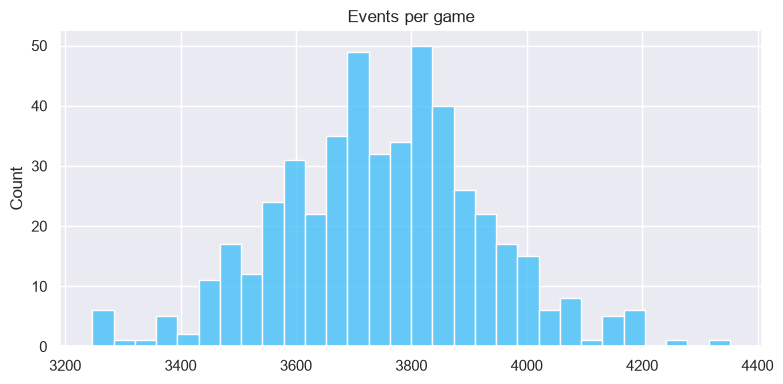

count     480.000000
mean     3750.966667
std       179.292017
min      3247.000000
25%      3637.000000
50%      3752.000000
75%      3865.000000
max      4352.000000
dtype: float64


In [22]:
events_per_game = events_df.groupby("game_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(events_per_game, bins=30, ax=ax, color="#38bdf8")
ax.set_title("Events per game")
plt.tight_layout()
plt.show()
print(events_per_game.describe())

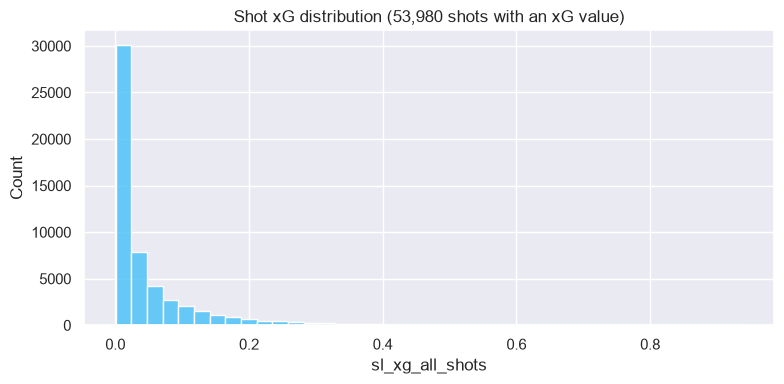

count    53980.000000
mean         0.051531
std          0.087541
min          0.000610
25%          0.004269
50%          0.017911
75%          0.059308
max          0.938368
Name: sl_xg_all_shots, dtype: float64


In [23]:
xg = events_df["sl_xg_all_shots"].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(xg, bins=40, ax=ax, color="#38bdf8")
ax.set_title(f"Shot xG distribution ({len(xg):,} shots with an xG value)")
ax.set_xlabel("sl_xg_all_shots")
plt.tight_layout()
plt.show()
print(xg.describe())